In [1]:
from experiments.query_based.WEB.retrain import df_result
%reload_ext autoreload
%autoreload 2
import sys

sys.path.append("../../..")

In [2]:
import pandas as pd

from tqdm import tqdm
from pathlib import Path

from ltr_utility.dataset import load_query_similarity, load_by_query_dataset, DatasetName
from ltr_utility.model_selection import evaluate, show_distr_conf, custom_train

from experiments.wrappers import *

In [3]:
base_path = Path("../../../datasets")
base_result = Path("results")
base_result.mkdir(parents=True, exist_ok=True)

In [4]:
eval_at = [1, 2, 3, 4, 6, 8, 10, 12, 15, 20, 25]
hold_out = (0.5, 0.2, 0.3)
iqr_trim = None  #(25, 75)
query_groups = load_query_similarity(Path("results"))

In [5]:
train, valid, test, train_valid = load_by_query_dataset(base_path, DatasetName.WEB10, hold_out=hold_out)

Loading train dataset from cache.
Train data loaded from cache.
Loading valid dataset from cache.
Valid data loaded from cache.
Loading test dataset from cache.
Test data loaded from cache.
---- WEB10K loaded ----
Filtered out 187 queries with fewer than 10 documents.
---- discard_minority_groups 10 queries ----
---- Get first 500 queries ----
---- max_item 400 -(determistic!) ----
---- Holdout (0.5, 0.2, 0.3) - (determistic!) ----


# LambdaMART

In [ ]:
lm_ms = pd.read_json(base_result / "lm_query_model_selection.json")
lm_conf_dist = show_distr_conf(lm_ms)

In [ ]:
lm_result = custom_train(
    base_result,
    train_valid,
    test,
    {1:243, 2:267, 4:267, 6:283, 8:261, 10:303, 50:239, 100:318},
    "lm_query_model_selection.json",
    lm_ms,
    "LambdaMART",
    WrapperLGBMRanker
)

# KNN

In [ ]:
knn_ms = pd.read_json(base_result / "knn_query_model_selection.json")
knn_conf_dist = show_distr_conf(knn_ms)

In [ ]:
knn_result = custom_train(
    base_result,
    train_valid,
    test,
    {1:0, 2:10, 4:0, 6:0, 8:0 , 10:0, 50:10, 100:4},
    "knn_query_model_selection.json",
    knn_ms,
    "KNN Regressor",
    WrapperKNN
)

# RuleTreeRank

In [ ]:
rtr_ms = pd.read_json(base_result / "rtr_query_model_selection.json")
rtr_conf_dist = show_distr_conf(rtr_ms)

In [ ]:
rtr_result = custom_train(
    base_result,
    train_valid,
    test,
    {1:24, 2:57, 4:196, 6:65, 8:49, 10:137, 50:5, 100:5},
    "rtr_query_model_selection.json",
    rtr_ms,
    "RuleTreeRank",
    WrapperRTR,
    rtr=True
)

# Mixed RuleTreeRank

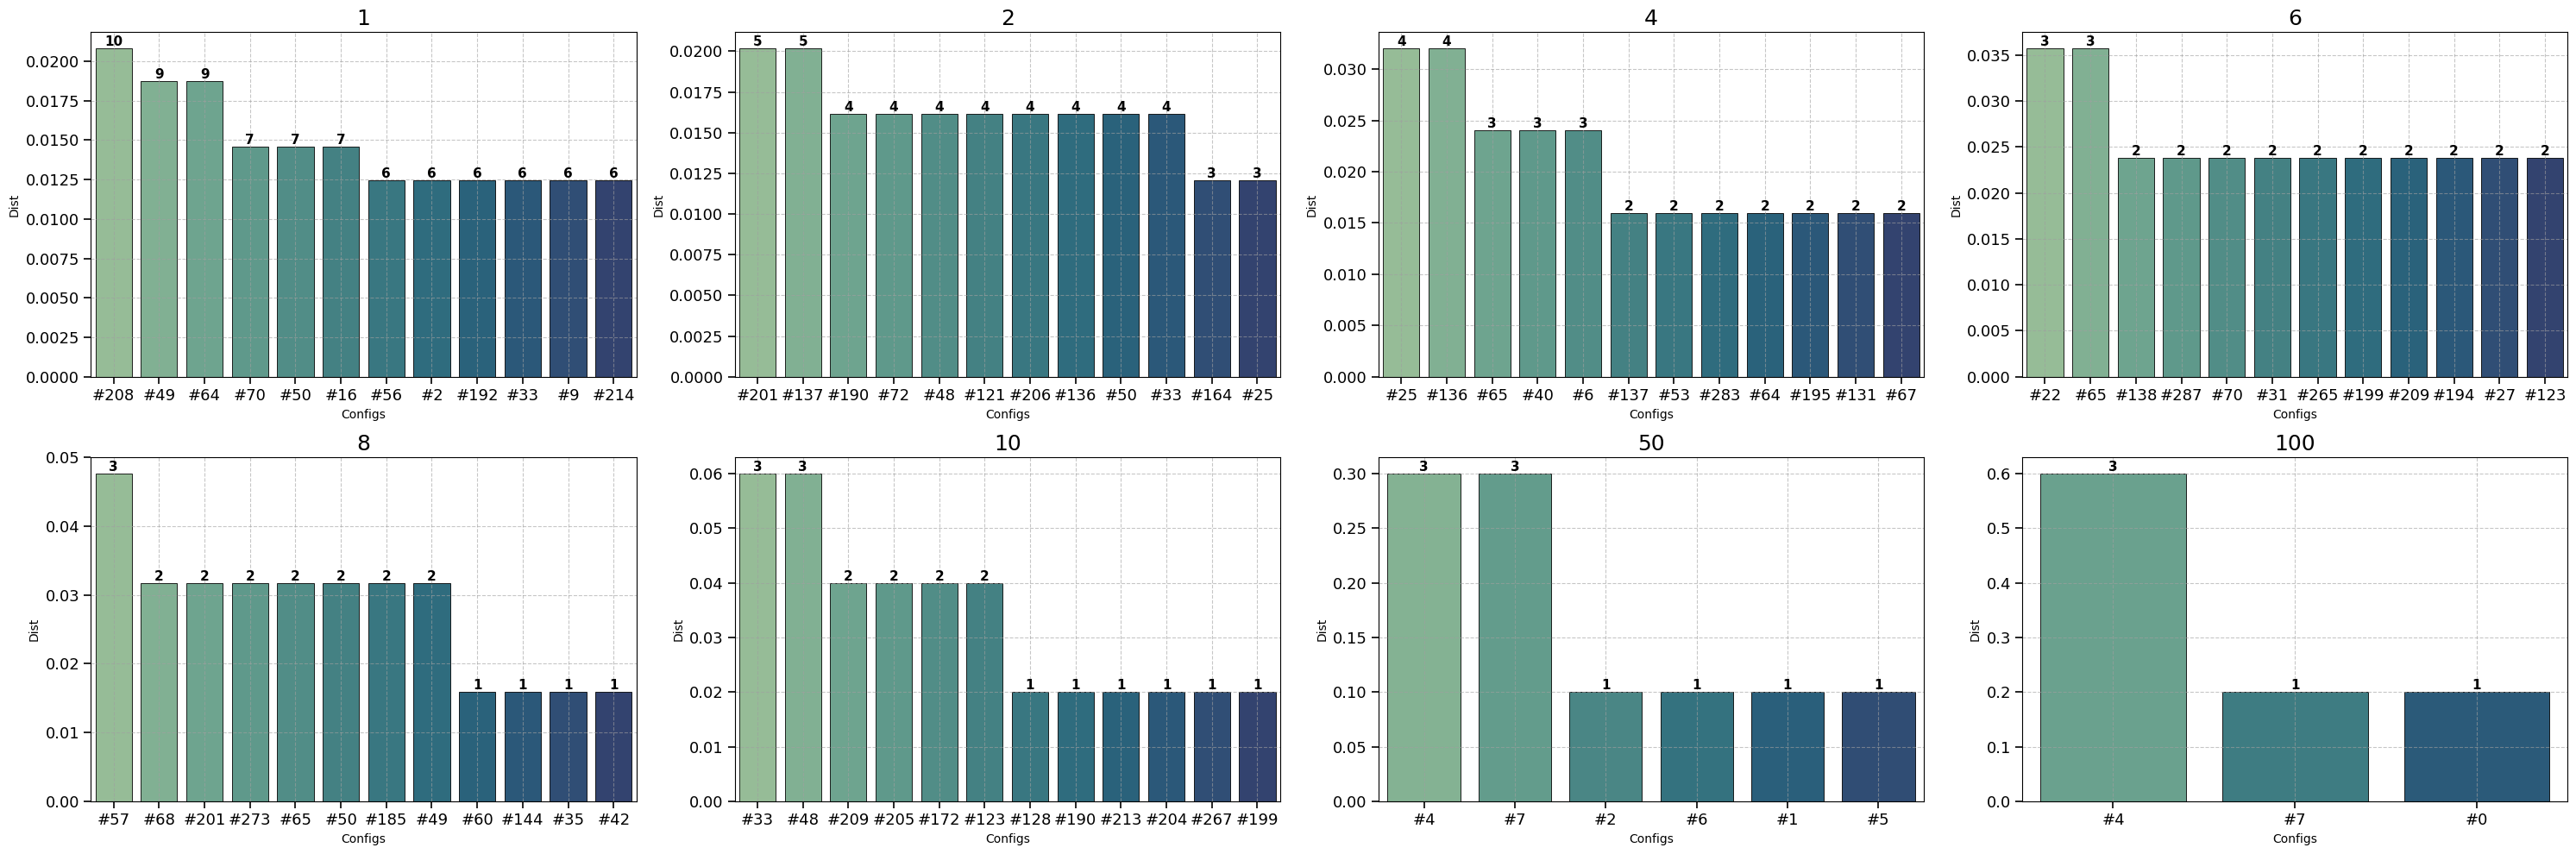

In [13]:
mix_rtr_ms = pd.read_json(base_result / "mix_rtr_query_model_selection.json")
mix_rtr_conf_dist = show_distr_conf(mix_rtr_ms)

In [22]:
mix_rtr_result = custom_train(
    base_result,
    train_valid,
    test,
    {1:208, 2:201, 4:25, 6:22, 8:57, 10:33, 50:4, 100:4},
    "mix_rtr_query_model_selection.json",
    mix_rtr_ms,
    "Mix-RuleTreeRank",
    WrapperMixRTR,
    rtr=True
)

1
Training with one-shot mode (dict params).


Training: 100%|██████████| 500/500 [01:48<00:00,  4.62it/s]


Eval
2
Training with one-shot mode (dict params).


Training: 100%|██████████| 250/250 [01:13<00:00,  3.38it/s]


Eval
4
Training with one-shot mode (dict params).


...

Eval
50
Training with one-shot mode (dict params).


Training: 100%|██████████| 10/10 [00:36<00:00,  3.63s/it]


Eval
100
Training with one-shot mode (dict params).


Training: 100%|██████████| 5/5 [00:34<00:00,  6.90s/it]


Eval


# KNN PDT

In [6]:
tmp_results = pd.read_pickle("temp.pkl")

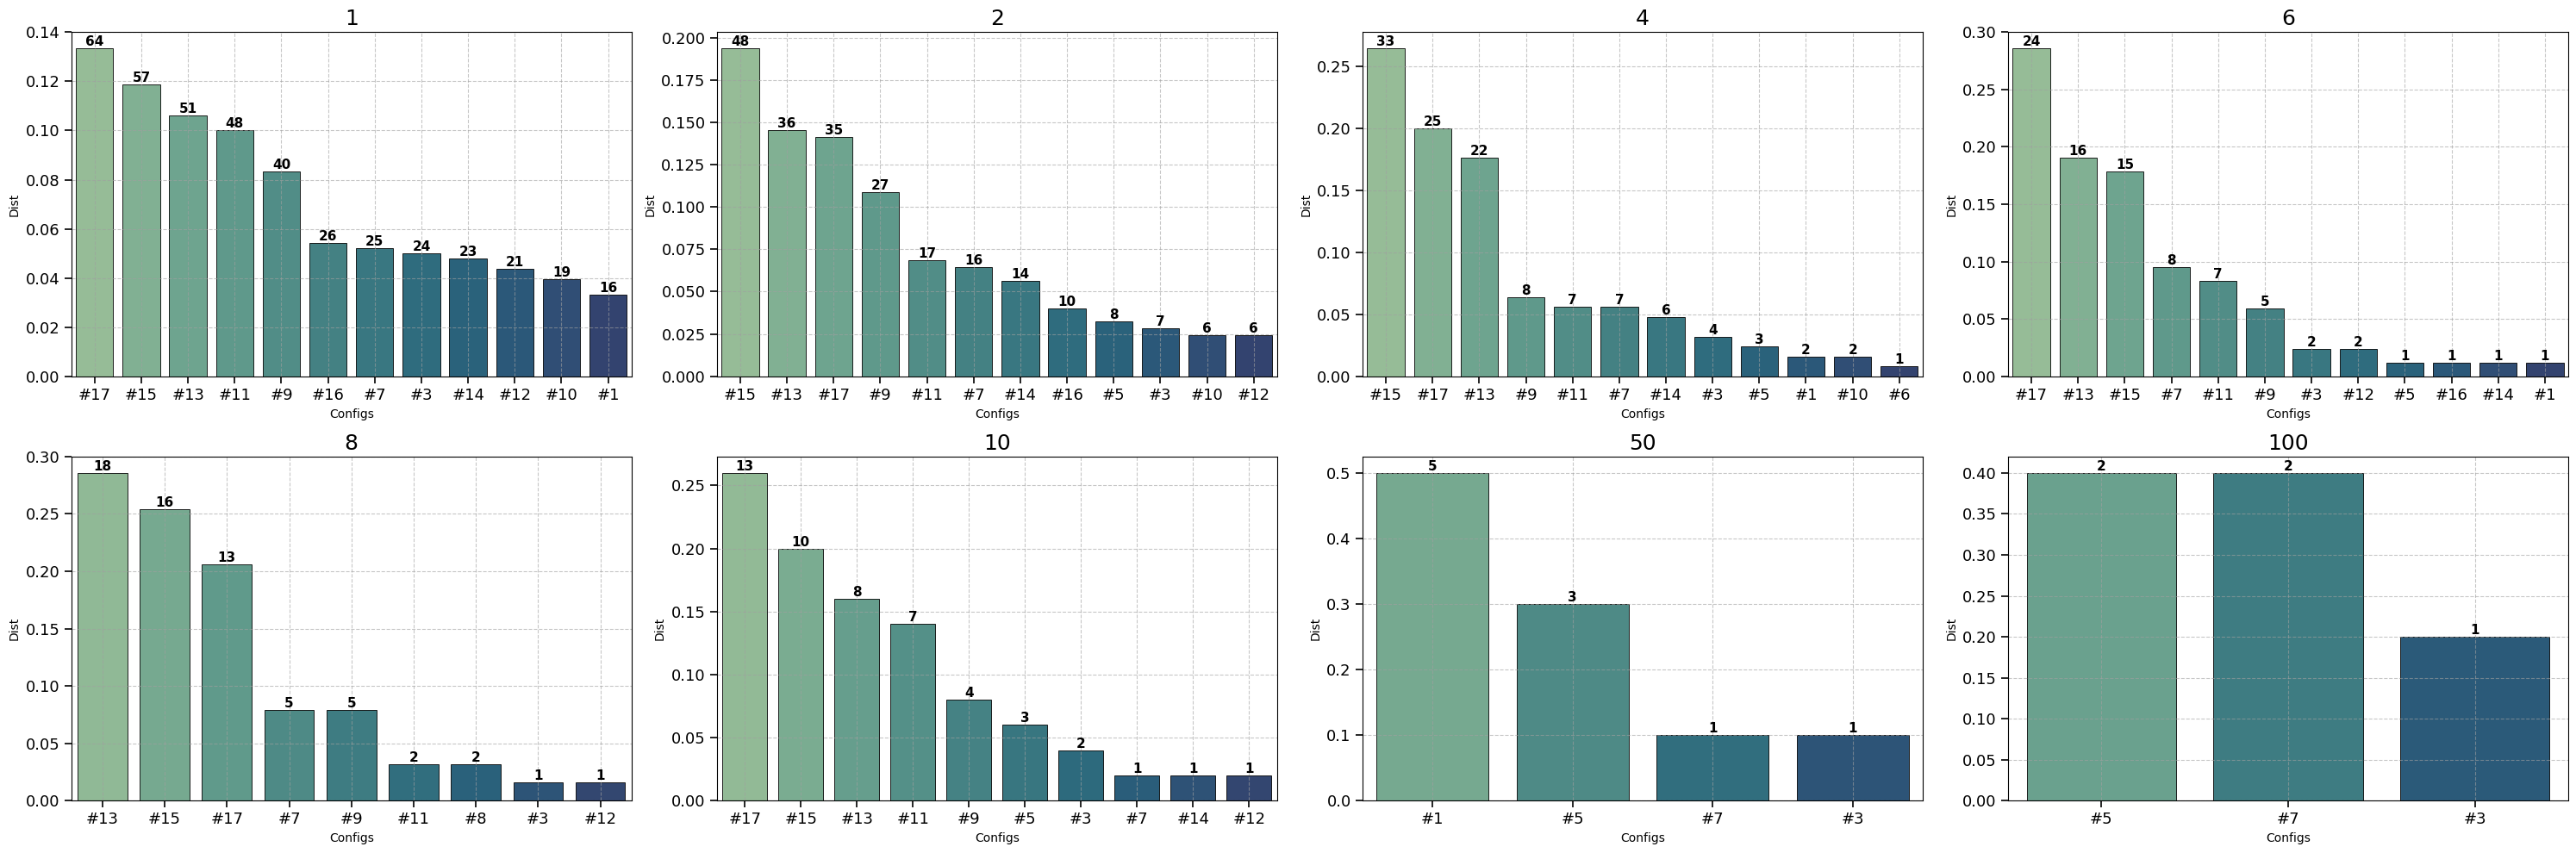

In [7]:
knn_pdt_ms = pd.read_json(base_result / "knn_pdt_query_model_selection.json")
knn_pdt_conf_dist = show_distr_conf(knn_pdt_ms)

In [8]:
knn_pdt_result = custom_train(
    base_result,
    train_valid,
    test,
    {1:17, 2:15, 4:15, 6:17, 8:13, 10:17, 50:1, 100:5},
    "knn_pdt_query_model_selection.json",
    knn_pdt_ms,
    "KNNwPDT",
    WrapperKNNPDT,
    rtr=True
)

1
Training with one-shot mode (dict params).


Training: 100%|██████████| 500/500 [02:15<00:00,  3.69it/s]


Eval
2
Training with one-shot mode (dict params).


Training: 100%|██████████| 250/250 [04:30<00:00,  1.08s/it]


Eval
4
Training with one-shot mode (dict params).


...

Eval
50
Training with one-shot mode (dict params).


Training: 100%|██████████| 10/10 [1:56:32<00:00, 699.24s/it]


Eval
100
Training with one-shot mode (dict params).


Training: 100%|██████████| 5/5 [6:08:40<00:00, 4424.15s/it]  


Eval


In [9]:
from ltr_utility.model_selection.retrain import retrain_evaluate

random_result = retrain_evaluate(
    train_valid=train_valid,
    test=test,
    configs={i: (None, {}) for i in [1, 2, 4, 6, 8, 10, 50, 100]},
    model=RandomRanker, name="RandomRanker")

Training with one-shot mode (dict params).


Training: 100%|██████████| 500/500 [00:00<00:00, 5823.68it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 250/250 [00:00<00:00, 6576.08it/s]


Training with one-shot mode (dict params).


...

Training: 100%|██████████| 50/50 [00:00<00:00, 4628.04it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 10/10 [00:00<00:00, 922.43it/s]


Training with one-shot mode (dict params).


Training: 100%|██████████| 5/5 [00:00<00:00, 756.49it/s]


# Evalutate results

In [ ]:
df_result = pd.concat([
    knn_pdt_result,
    knn_result,
    lm_result,
    mix_rtr_result,
    rtr_result,
    random_result,
], axis=0)


In [21]:
pd.concat([
    results,
    pd.read_json(base_result / "ilmart_query_model_selection.json"),
    pd.read_json(base_result / "listnet_query_model_selection.json"),
], axis=0).to_json(base_result / "WEB_result.json", orient="records")

In [25]:
# results = []
# df_result = pd.concat([mix_rtr_result, knn_pdt_result], axis=0)
# for _, row in tqdm(df_result.iterrows(), total=len(df_result)):
#     for k in eval_at:
#         res = evaluate(row["pred_test"], test.y, test.group_count, k=k,
#                        weight=False, aggregated=False)
#         results.append((row["model"], "test", row["qxm"], k, res))
#
# results = pd.DataFrame(results, columns=["model", "fold", "qxm", "k", "ndcg_s"])
# results.to_json("WEB_noagg.json")

In [24]:
# results = []
# df_result = pd.concat([mix_rtr_result, knn_pdt_result], axis=0)
# for _, row in tqdm(df_result.iterrows(), total=len(df_result)):
#     for k in eval_at:
#         res = evaluate(row["pred_test"], test.y, test.group_count, k=k,
#                        weight=True, aggregated=False)
#         results.append((row["model"], "test", row["qxm"], k, res))
#
# results = pd.DataFrame(results, columns=["model", "fold", "qxm", "k", "ndcg_s"])
# results.to_json("WEB_noagg_weight.json")

100%|██████████| 48/48 [01:15<00:00,  1.58s/it]
